## Environment Setup and Imports

The required libraries are imported to support data preprocessing, Random Forest Regression, hyperparameter optimization, model evaluation, feature importance analysis, and model persistence.

In [3]:
import os
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

## Load Training and Testing Data

The prepared training and testing datasets are loaded from the processed data directory.

The predefined train-test split is reused to ensure a consistent and fair comparison between the different regression models.

In [4]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test :", X_test.shape, "| y_test :", y_test.shape)

print("\nTraining features:")
print(X_train.head())

X_train: (13463, 6) | y_train: (13463,)
X_test : (3366, 6) | y_test : (3366,)

Training features:
          Locality   Latitude  Longitude  Signal Strength (dBm)  Latency (ms)  \
0      Pataliputra  25.605539  85.285651             -87.611830    164.101054   
1       Kidwaipuri  25.491973  85.086669             -90.089704     22.851745   
2          Danapur  25.684972  84.989785             -90.175391    139.812003   
3       Kankarbagh  25.569868  85.138714             -93.384826    113.904981   
4  Phulwari Sharif  25.626811  85.136823             -95.888704     71.291449   

  Network Type  
0           4G  
1           5G  
2           4G  
3           4G  
4           4G  


## Define Numerical and Categorical Features

The input features are divided into numerical and categorical groups to apply the appropriate preprocessing strategy before training the Random Forest model.

In [5]:
numerical_features = [
    "Latitude",
    "Longitude",
    "Signal Strength (dBm)",
    "Latency (ms)"
]

categorical_features = [
    "Locality",
    "Network Type"
]

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Latitude', 'Longitude', 'Signal Strength (dBm)', 'Latency (ms)']

Categorical features:
['Locality', 'Network Type']


## Configure Feature Preprocessing

Numerical features are passed through without scaling because Random Forest is not sensitive to feature magnitude.

Categorical features are transformed using OneHotEncoder to convert categorical values into a numerical representation suitable for the regression model.

In [6]:
rf_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features
        )
    ]
)

print("Random Forest preprocessing pipeline configured successfully.")

Random Forest preprocessing pipeline configured successfully.


## Construct the Random Forest Regression Pipeline

A unified machine learning pipeline is created by combining the feature preprocessing stage with the Random Forest Regressor.

The pipeline ensures that preprocessing and model training are handled consistently during cross-validation and final model training.

In [7]:
rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            rf_preprocessor
        ),
        (
            "model",
            RandomForestRegressor(
                random_state=42
            )
        )
    ]
)

print("Random Forest pipeline created successfully.")

Random Forest pipeline created successfully.


## Define the Hyperparameter Search Space

A hyperparameter search space is defined for the Random Forest model.

The search focuses on the number of trees and the maximum tree depth. Five-fold cross-validation with negative Mean Absolute Error is used to identify the configuration that provides the best generalization performance.

In [8]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20, None]
}

print("Hyperparameter search space:")
print(param_grid)

Hyperparameter search space:
{'model__n_estimators': [100, 200], 'model__max_depth': [10, 20, None]}


## Optimize Random Forest Using Cross-Validation

GridSearchCV is used to evaluate the defined Random Forest configurations using five-fold cross-validation.

The configuration with the lowest Mean Absolute Error is selected as the best model based on its cross-validation performance.

In [9]:
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Grid search completed successfully.")

Grid search completed successfully.


## Identify the Optimal Random Forest Configuration

The best hyperparameter configuration and its corresponding cross-validation performance are retrieved from the completed grid search.

Because Scikit-learn maximizes scoring values, Mean Absolute Error is represented as a negative score during hyperparameter optimization.

In [10]:
best_params = grid_search.best_params_
best_cv_mae = -grid_search.best_score_
best_rf_pipeline = grid_search.best_estimator_

print("Best parameters:")
print(best_params)

print(f"\nBest Cross-Validation MAE: {best_cv_mae:.4f}")

Best parameters:
{'model__max_depth': 10, 'model__n_estimators': 100}

Best Cross-Validation MAE: 6.3274


## Generate Training and Testing Predictions

The optimized Random Forest pipeline is used to generate throughput predictions for both the training and testing datasets.

Comparing the two sets of predictions helps assess the model's ability to generalize to unseen data.

In [11]:
y_pred_train = best_rf_pipeline.predict(X_train)
y_pred_test = best_rf_pipeline.predict(X_test)

print("Training predictions generated:", y_pred_train.shape)
print("Testing predictions generated :", y_pred_test.shape)

Training predictions generated: (13463,)
Testing predictions generated : (3366,)


## Evaluate Random Forest Regression Performance

The optimized Random Forest model is evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

Both training and testing performance are reported to assess prediction accuracy and generalization to unseen data.

In [12]:
train_mae = mean_absolute_error(y_train, y_pred_train)
train_mse = mean_squared_error(y_train, y_pred_train)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_pred_train)

test_mae = mean_absolute_error(y_test, y_pred_test)
test_mse = mean_squared_error(y_test, y_pred_test)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_pred_test)

print("Training Performance")
print(f"MAE  : {train_mae:.4f}")
print(f"MSE  : {train_mse:.4f}")
print(f"RMSE : {train_rmse:.4f}")
print(f"R²   : {train_r2:.4f}")

print("\nTest Performance")
print(f"MAE  : {test_mae:.4f}")
print(f"MSE  : {test_mse:.4f}")
print(f"RMSE : {test_rmse:.4f}")
print(f"R²   : {test_r2:.4f}")

Training Performance
MAE  : 5.7331
MSE  : 140.8812
RMSE : 11.8693
R²   : 0.7857

Test Performance
MAE  : 6.4640
MSE  : 177.9207
RMSE : 13.3387
R²   : 0.7355


## Compare Against a Baseline Model

A simple baseline model is used to provide a reference point for evaluating the Random Forest performance.

The DummyRegressor predicts the mean target value for every sample. The Random Forest should achieve a substantially lower Mean Absolute Error if it is effectively learning useful relationships from the input features.

In [13]:
dummy_model = DummyRegressor(strategy="mean")

dummy_model.fit(X_train, y_train)

y_pred_dummy = dummy_model.predict(X_test)

baseline_mae = mean_absolute_error(
    y_test,
    y_pred_dummy
)

print(f"Baseline MAE: {baseline_mae:.4f}")
print(f"Random Forest MAE: {test_mae:.4f}")

Baseline MAE: 19.2824
Random Forest MAE: 6.4640


## Visualize Actual vs Predicted Throughput

The actual and predicted throughput values are visualized to assess how closely the Random Forest predictions follow the observed target values.

The reference line represents ideal predictions, where the predicted throughput is equal to the actual throughput.

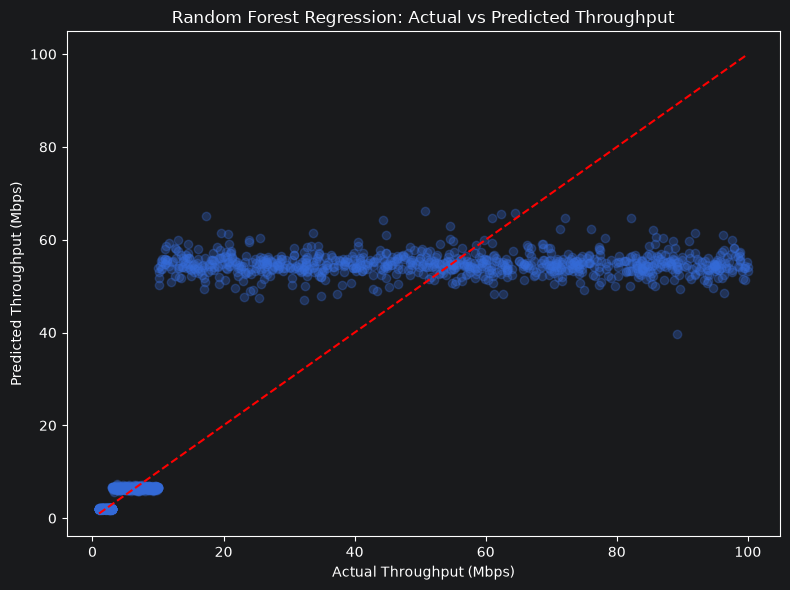

In [14]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_test,
    alpha=0.3
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual Throughput (Mbps)")
plt.ylabel("Predicted Throughput (Mbps)")
plt.title("Random Forest Regression: Actual vs Predicted Throughput")

plt.tight_layout()
plt.show()

## Analyze Feature Importance

Feature importance is extracted from the trained Random Forest model to identify the transformed features that contribute most to the prediction of data throughput.

The encoded feature names are retrieved from the preprocessing pipeline to make the importance results interpretable.

In [15]:
importances = best_rf_pipeline.named_steps["model"].feature_importances_

feature_names = (
    best_rf_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

print(importance_df.head(15))

                            Feature  Importance
26             cat__Network Type_5G    0.675543
3                 num__Latency (ms)    0.281339
2        num__Signal Strength (dBm)    0.011557
0                     num__Latitude    0.011520
1                    num__Longitude    0.011454
21    cat__Locality_Phulwari Sharif    0.000722
16         cat__Locality_Kankarbagh    0.000597
20  cat__Locality_Patliputra Colony    0.000578
23          cat__Locality_S.K. Puri    0.000576
13        cat__Locality_Fraser Road    0.000537
4           cat__Locality_Anandpuri    0.000524
22     cat__Locality_Rajendra Nagar    0.000496
12    cat__Locality_Exhibition Road    0.000488
8           cat__Locality_Bankipore    0.000471
10        cat__Locality_Boring Road    0.000400


## Visualize Feature Importance

The most important transformed features are visualized to provide an interpretable overview of the factors used most strongly by the Random Forest model during prediction.

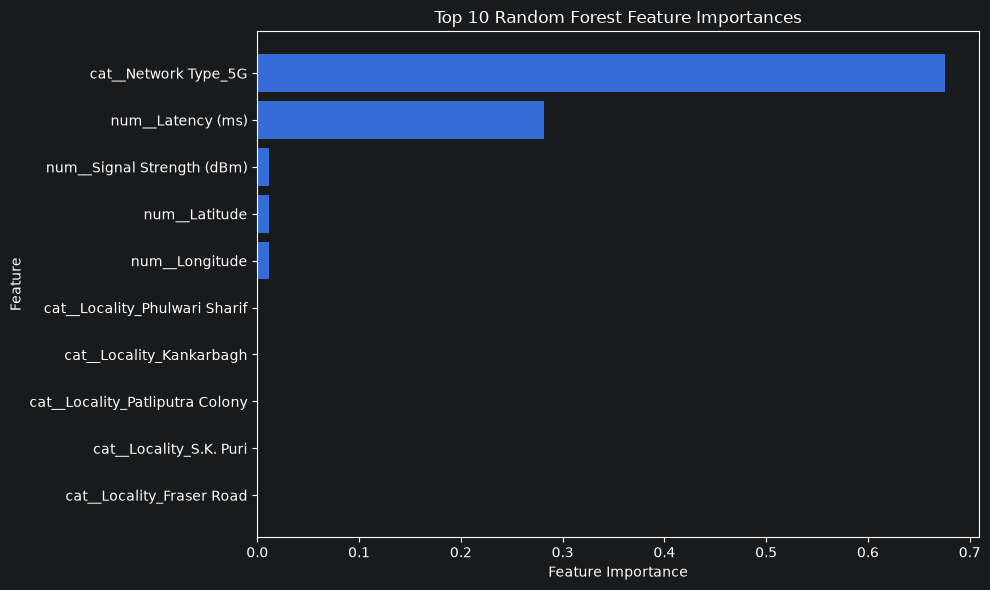

In [16]:
top_features = importance_df.head(10).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Feature Importances")

plt.tight_layout()
plt.show()

## Save the Optimized Random Forest Pipeline

The optimized Random Forest pipeline, including both feature preprocessing and the trained regression model, is saved as a Joblib file.

Saving the complete pipeline allows the same preprocessing steps and trained model to be reused directly in the Streamlit application without retraining.

In [17]:
model_path = "../models/random_forest.joblib"

joblib.dump(
    best_rf_pipeline,
    model_path
)

print(f"Random Forest pipeline saved successfully to: {model_path}")

Random Forest pipeline saved successfully to: ../models/random_forest.joblib
